<a href="https://colab.research.google.com/github/oridoll/Mini_projets/blob/test_vit_cnn/vit_vs_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VIT vs CNN

The objective of this project is to compare the performances of two differents architectures for the task of image classification: Vision Transformers (ViT) and Convolutional Neural Networks (CNN). A Convolutionnal Neural Networtk is a specialized neural network designed to classify and to process images by using a local information from adjacent pixels. Its firsts layers are a combination of Convolution and Pooling layers and the last layers are a fully-connected or dense layer. A Vision Transformer uses the auto-attention mechanism to consider the relationship between all the patches of the images. 
Acccording to this paper [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://doi.org/10.48550/arXiv.2010.11929) : CNN are better over small datasets thant ViT. This what we study in this notebook.

 It is better on small datasets because there is less global parameters to learn
 It needs a large quantity of data to learn these relations without the advantage of local induction.

### Comparison of the architecture of a CNN and a ViT

reprendre le cours et expliquer (c'est la question 2) "Make sure to explain the ViT architecture in detail." JE SAIS PAS SI LA LICENSE DE L'IMAGE ESST VALIDE https://github.com/google-research/vision_transformer

![ViT](vit.png "ViT")
![CNN](cnn_architecture.png "CNN")


### Choice of the two datasets

We chose to use the dataset CIFAR10 and STL10. We explain why below.

In [2]:
#%load_ext autoreload
#%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


For the fisrt dataset, we propose CIFAR10 https://www.cs.toronto.edu/~kriz/cifar.html

| Shape | Number of classes | Dataset |
|:-------- |:--------:| --------:|
| 32 x 32 pixels RGB | 10   | 60000 images  |

The training dataset has 50000 images and the test dataset has 10000 images.
<p>Justification :

<p>Small images require low-level feature extraction. This allows testing whether a basic ViT (which uses large patches, e.g., 16x16) can outperform a CNN like LeNet or VGG on low-resolution images. This dataset has a small complexity so it can concentrate on the architecture over the rarity of the classes. A small volume of data allowed a fast training and i ideal to test models from scratch.

In [4]:
from torchvision import datasets, transforms

batch_size = 128

# Data loading - WITH CORRECT CIFAR-10 NORMALIZATION
# Standard CIFAR-10 statistics: mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
transform_cifar10 = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])
train_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=True, transform=transform_cifar10, download=True)
test_dataset_cifar10 = datasets.CIFAR10(root='cifar10', train=False, transform=transform_cifar10, download=True)

train_loader_cifar10 = torch.utils.data.DataLoader(dataset=train_dataset_cifar10, batch_size=batch_size, shuffle=True)
test_loader_cifar10 = torch.utils.data.DataLoader(dataset=test_dataset_cifar10, batch_size=batch_size, shuffle=False)

100%|██████████| 170M/170M [02:28<00:00, 1.14MB/s] 


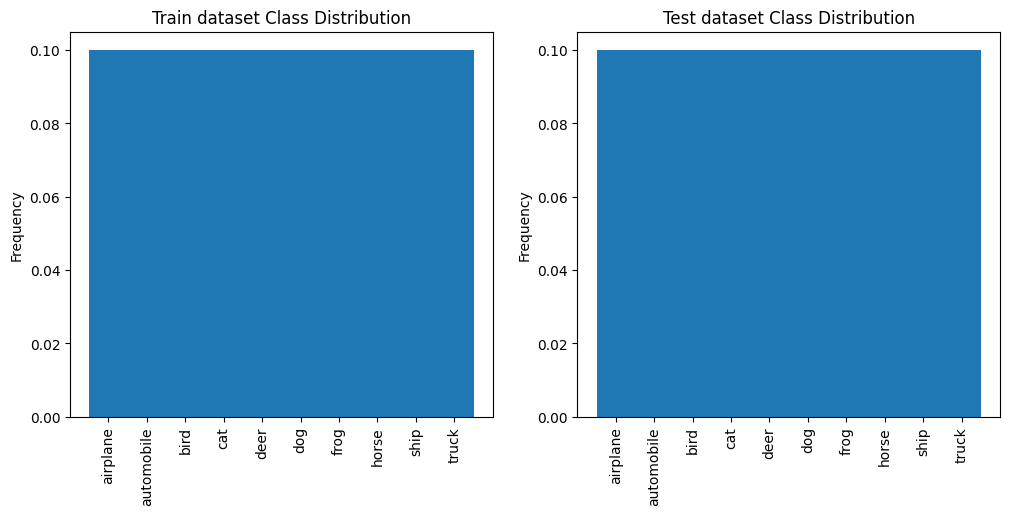

In [5]:
def get_data_statistics(dataset, ax, title):
    ax.hist(dataset.classes, bins=np.arange(11)-0.5, density=True)

    #plt.set_xticks(np.arange(10))
    #plt.set_xticklabels(list(dataset.classes))
    ax.set_ylabel('Frequency')
    ax.tick_params(axis='x', rotation=90)
    ax.set_title(title)
    

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
title_train = 'Train dataset Class Distribution'
title_test = 'Test dataset Class Distribution'
get_data_statistics(train_dataset_cifar10, ax1, title_train)
get_data_statistics(test_dataset_cifar10, ax2, title_test)
plt.show()

One can observe that we have a perfect repartition between all the classes for the training and test dataset.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9100897..2.100835].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7709224..1.7256967].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0432324].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.0298588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8465825..2.0137537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594

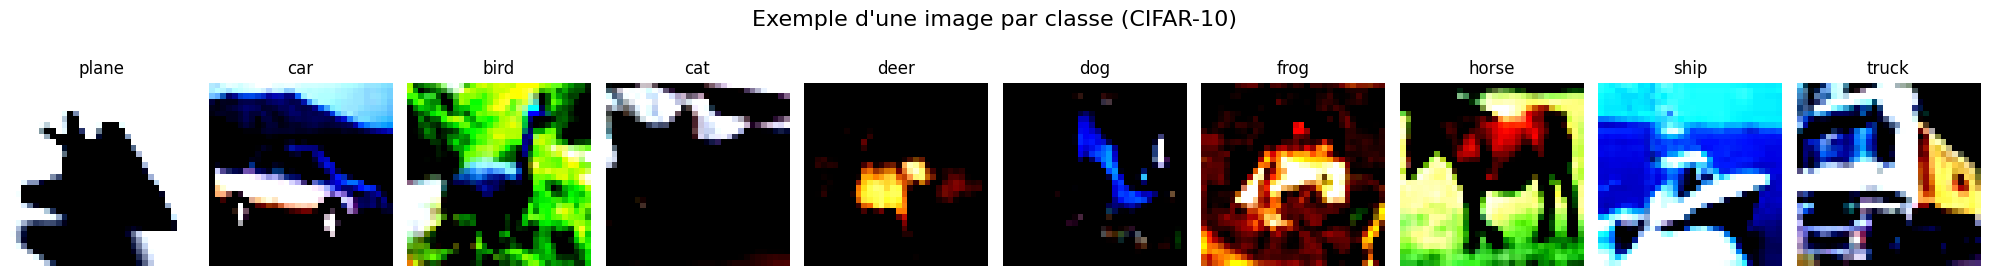


Dimensions d'une image (Tensor) : torch.Size([3, 32, 32])
Plage de valeurs d'un pixel (après ToTensor) : -1.9481 à 2.1104


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Classes from CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Collect the indexes of one image per class
num_classes = len(classes)
samples_per_class = 1
indices_to_display = {}

# Find an index per class
for i in range(len(train_dataset_cifar10)):
    _, label = train_dataset_cifar10[i]
    if label not in indices_to_display:
        indices_to_display[label] = i
        if len(indices_to_display) == num_classes:
            break

# Plot
fig, axes = plt.subplots(1, num_classes, figsize=(20, 3))
fig.suptitle("Exemple d'une image par classe (CIFAR-10)", fontsize=16)

for label, index in indices_to_display.items():
    image_tensor, _ = train_dataset_cifar10[index]
    image_np = image_tensor.numpy().transpose((1, 2, 0))

    # Plot
    ax = axes[label]
    ax.imshow(image_np)
    ax.set_title(classes[label])
    ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Print the Tensor of one images to check the dimensions and pixel value range
print(f"\nDimensions d'une image (Tensor) : {image_tensor.shape}")
print(f"Plage de valeurs d'un pixel (après ToTensor) : {image_tensor.min():.4f} à {image_tensor.max():.4f}")

For the second dataset, we propose STL10 https://cs.stanford.edu/~acoates/stl10/

| Shape | Number of classes | Dataset |
|:-------- |:--------:| --------:|
| 96 x 96 RGB | 10 |  images  |

The training dataset has 5000 images and the test dataset has 800 images.
<p>Justification :

<p>

In [7]:
from torchvision import datasets, transforms
import torch

batch_size = 64 # On réduit la taille du batch car les images sont plus grandes

# Normalisation spécifique pour STL-10
transform_stl10 = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.43, 0.43, 0.43], std=[0.27, 0.27, 0.27])])

# Chargement de STL-10
train_dataset_stl10 = datasets.STL10(root='data_stl10', split='train', transform=transform_stl10, download=True)
test_dataset_stl10 = datasets.STL10(root='data_stl10', split='test',transform=transform_stl10, download=True)

# Création des DataLoaders
train_loader_stl10 = torch.utils.data.DataLoader(dataset=train_dataset_stl10, batch_size=batch_size, shuffle=True)
test_loader_stl10 = torch.utils.data.DataLoader(dataset=test_dataset_stl10, batch_size=batch_size, shuffle=False)

print(f"Images d'entraînement (étiquetées) : {len(train_dataset_stl10)}")
print(f"Dimensions de la première image (Tensor) : {train_dataset_stl10[0][0].shape}")

100%|██████████| 2.64G/2.64G [49:58<00:00, 880kB/s]   


STL-10 chargé avec succès.
Images d'entraînement (étiquetées) : 5000
Dimensions de la première image (Tensor) : torch.Size([3, 96, 96])


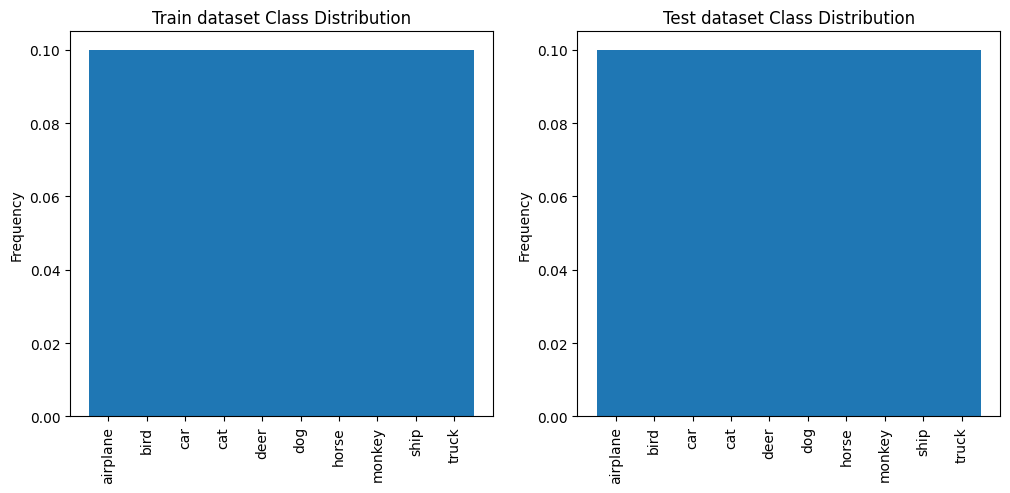

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
title_train = 'Train dataset Class Distribution'
title_test = 'Test dataset Class Distribution'
get_data_statistics(train_dataset_stl10, ax1, title_train)
get_data_statistics(test_dataset_stl10, ax2, title_test)
plt.show()

Similarly to the cifar-10 class distribution this one is perfectly balanced.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..1.9368191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.067538].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.0384893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..1.7915758].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5344952..

Affichage de 15 images aléatoires du premier batch.


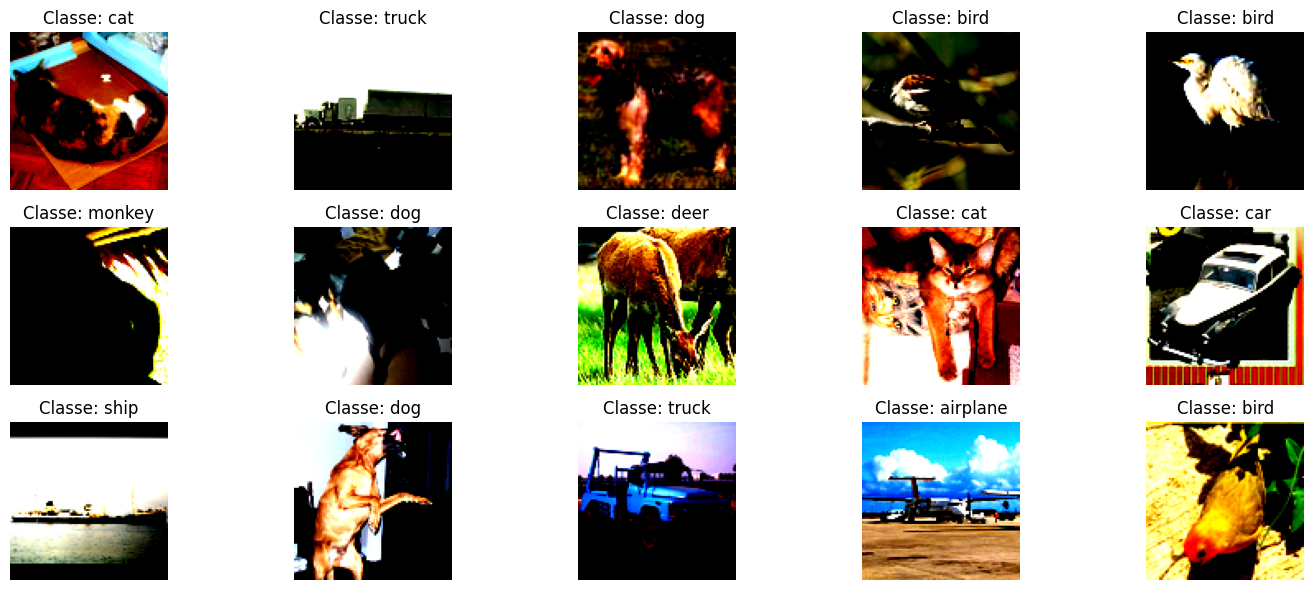


Dimensions d'un lot ImageNet : torch.Size([64, 3, 96, 96])
Plage de valeurs des pixels dans le lot : -1.5926 à 2.1111


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Récupérer un seul lot du DataLoader
dataiter = iter(train_loader_stl10)
images, labels = next(dataiter)

# Number of images to display
num_to_display = 15

fig, axes = plt.subplots(3, 5, figsize=(15, 6))
axes = axes.flatten() # Aplatir la grille d'axes pour un parcours facile

classes_ids = list(range(10)) # Simple liste des IDs 0 à 9
classes_dict = {0: 'airplane', 1: 'bird', 2: 'car', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'horse', 7: 'monkey', 8: 'ship', 9: 'truck',}

print(f"Affichage de {num_to_display} images aléatoires du premier batch.")

for i in range(num_to_display):
    # Convertir le Tensor (C, H, W) en NumPy (H, W, C)
    image_np = images[i].numpy().transpose((1, 2, 0))

    ax = axes[i]
    # L'affichage d'ImageNet nécessite généralement une dénormalisation si vous avez appliqué une normalisation
    # Pour l'instant, si vous utilisez seulement ToTensor(), l'affichage est direct.
    ax.imshow(image_np)

    # Class ID
    ax.set_title(f"Classe: {classes_dict[labels[i].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Check the dimensions and pixel value range of the batch
print(f"\nDimensions d'un lot ImageNet : {images.shape}")
print(f"Plage de valeurs des pixels dans le lot : {images.min():.4f} à {images.max():.4f}")

### Choice of ViT and CNN architectures

#### ViT

In [ ]:
# Créons la classe de notre ViT il s'agit la d'une première version naïve avec seulement un encoder.
# J'utilise https://www.geeksforgeeks.org/deep-learning/building-a-vision-transformer-from-scratch-in-pytorch/ 

# Un ViT se compose notamment d'une couche de patch embbeding, positional encoding, Multi head attention layer
# img_size = 32
# in_channels = 3
# embed_dim = 768
# patch_size = 16
# num_heads=8
# depth=6
# mlp_dim=1024
# num_classes=100
# seq_len = (img_size // patch_size) ** 2  # Nombre de patches

# Definition of the Patch Embedding. This layer converts the image into a sequence of patch embeddings.
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

# Definition of the Positional Encoding. This layer adds positional information to the patch embeddings.
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, seq_len):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len + 1, embed_dim))  # Adjusted for [CLS] token

    def forward(self, x):
        return x + self.pos_embed
    
# Definition of the Multi-Head Attention layer.
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)  # ✓ batch_first=True

    def forward(self, x):
        return self.attn(x, x, x)[0]

# Definition of a Transformer Encoder Block.
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.mlp = nn.Sequential(    # Feed Forward Network
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))  
        x = x + self.mlp(self.norm2(x))   
        return x

# Definition of the Vision Transformer (ViT) model.
class VisionTransformer(nn.Module):
    def __init__(self, img_size, patch_size, num_classes, embed_dim, num_heads, depth, mlp_dim):
        super().__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, (img_size // patch_size) ** 2)
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(depth)
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embedding(x)
        cls_tokens = self.cls_token.expand(B, -1, -1) # CLS token for each image
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.mlp_head(x[:, 0])
        return x

In [ ]:
def training_loop(model, optimizer, criterion, train_loader, test_loader, epochs):
    
    loss_liste = []
    val_loss_liste = []
    
    #Training loop
    for epoch in range(epochs):  # loop over epochs
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move to GPU if available
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        loss_liste.append(epoch_loss)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for batch_idx, (data, label) in enumerate(test_loader):
                data = data.to(device)
                label = label.to(device)
                recon_batch = model(data)  
                val_loss_batch = criterion(recon_batch, label)
                val_running_loss += val_loss_batch.item()
        
        epoch_val_loss = val_running_loss / len(test_loader)
        val_loss_liste.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss}, Val_Loss: {epoch_val_loss}")
    
    return loss_liste, val_loss_liste

In [12]:
epoch_num = 10

model_stl = VisionTransformer(
    img_size=96,  # STL-10 est 96x96
    patch_size=16,
    num_classes=10,  # STL-10 a 10 classes
    embed_dim= 8*32,
    num_heads=8,
    depth=6,
    mlp_dim=1024
).to(device)
model_cifar = VisionTransformer(
    img_size=32,  # CIFAR-10 est 32x32
    patch_size=16,
    num_classes=10,  # CIFAR-10 a 10 classes
    embed_dim= 8*32,
    num_heads=8,
    depth=6,
    mlp_dim=1024
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) #label_smoothing=0.1
optimizer_stl = optim.Adam(model_stl.parameters(), lr=0.001)
optimizer_cifar = optim.Adam(model_cifar.parameters(), lr=0.001)

loss_liste_stl, val_loss_liste_stl = training_loop(model=model_stl, optimizer=optimizer_stl, criterion=criterion, train_loader=train_loader_stl10, test_loader=test_loader_stl10, epochs=epoch_num)
loss_liste_cifar, val_loss_liste_cifar = training_loop(model=model_cifar, optimizer=optimizer_cifar, criterion=criterion, train_loader=train_loader_cifar10, test_loader=test_loader_cifar10, epochs=epoch_num)

Epoch [1/10], Loss: 2.523861050605774, Val_Loss: 2.0859200239181517
Epoch [2/10], Loss: 1.8911154587057573, Val_Loss: 1.8568811531066896
Epoch [3/10], Loss: 1.7599447165863424, Val_Loss: 1.7697596349716187
Epoch [4/10], Loss: 1.6391788132583038, Val_Loss: 1.7810482273101806
Epoch [5/10], Loss: 1.55039595803128, Val_Loss: 1.7216404218673707
Epoch [6/10], Loss: 1.4569818611386456, Val_Loss: 1.8197974109649657
Epoch [7/10], Loss: 1.342603754393662, Val_Loss: 1.7895414667129517
Epoch [8/10], Loss: 1.2690975809399085, Val_Loss: 1.8898297939300537
Epoch [9/10], Loss: 1.1845822877521757, Val_Loss: 1.9064698600769043
Epoch [10/10], Loss: 1.1089560563051248, Val_Loss: 1.9221586894989013
Epoch [1/10], Loss: 1.9051350440515582, Val_Loss: 1.677265283427661
Epoch [2/10], Loss: 1.614259492100962, Val_Loss: 1.5912664449667628
Epoch [3/10], Loss: 1.5260766644002226, Val_Loss: 1.5942743986467771
Epoch [4/10], Loss: 1.4684359030345517, Val_Loss: 1.5279619301421732
Epoch [5/10], Loss: 1.4191426221671921,

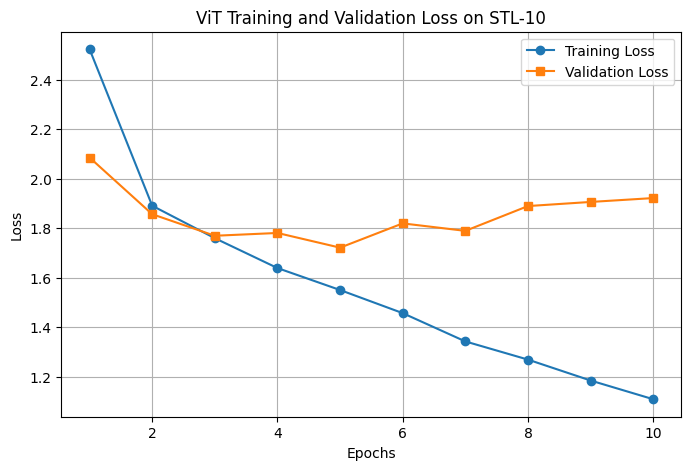

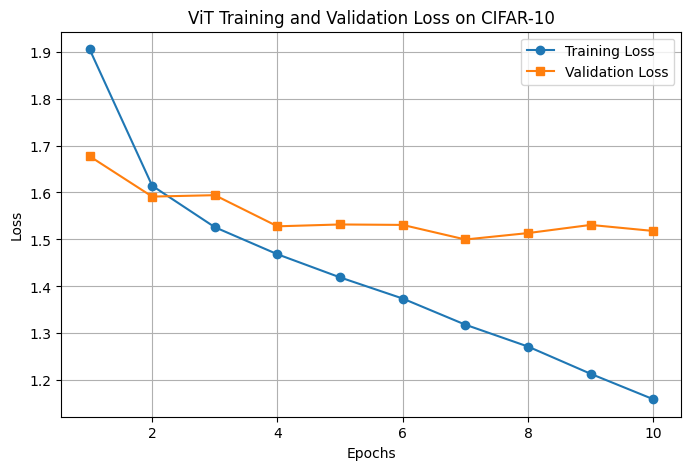

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epoch_num+1), loss_liste_stl, marker='o', label='Training Loss')
plt.plot(range(1, epoch_num+1), val_loss_liste_stl, marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ViT Training and Validation Loss on STL-10')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1, epoch_num+1), loss_liste_cifar, marker='o', label='Training Loss')
plt.plot(range(1, epoch_num+1), val_loss_liste_cifar, marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ViT Training and Validation Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()


The ViT model is of an approximatly 5 million parameters size. On the STL-10 dataset one can observe that the model is overfitting. It is quite logical considering that there is only 5000 images of size 96x96. Some solutions are available. We can add dropout, train the ViT on a set of augmented datas, reduce the number of epoch (less preferable). The training on CIFAR-10 however is not overfitting.

In the following cell we use a fonction that allows access to the global accuracy of the model. It also provides a display of some predictions made by the model compared to the expected results.

In [38]:
def evaluate_and_visualize(model, test_loader, num_images, dataset_name):
    """
    Évalue le modèle sur l'ensemble de validation et affiche les prédictions avec les images.
    
    Args:
        model: Le modèle à évaluer
        test_loader: DataLoader pour l'ensemble de test
        num_images: Nombre d'images à afficher (par défaut 15)
        dataset_name: Nom du dataset pour les classes (par défaut "CIFAR-10")
    """
    
    # Classes CIFAR-10 et STL-10
    classes_cifar10 = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    classes_stl10 = ('airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck')
    
    # Dictionnaire pour mapper le nom du dataset aux classes
    classes_dict = {
        "CIFAR-10": classes_cifar10,
        "STL-10": classes_stl10
    }
    
    classes = classes_dict[dataset_name]
    
    model.eval()
    all_predictions = []
    all_labels = []
    all_images = []
    
    # Collecter les prédictions
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.append(predicted.cpu())
            all_labels.append(labels.cpu())
            all_images.append(images.cpu())
    
    # Convertir en tenseurs
    all_predictions = torch.cat(all_predictions, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    all_images = torch.cat(all_images, dim=0)
    
    # Calculer l'accuracy globale
    correct = (all_predictions == all_labels).sum().item()
    total = all_labels.size(0)
    accuracy = 100 * correct / total
    
    print(f"\n{'='*70}")
    print(f"RÉSULTATS DE VALIDATION - {dataset_name}")
    print(f"{'='*70}")
    print(f"Accuracy globale: {accuracy:.2f}% ({correct}/{total})")
    print(f"{'='*70}\n")
    
    # Afficher les images avec les prédictions
    num_rows = num_images // 5 + int(num_images % 5 != 0)
    num_cols = 5
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 9))
    axes = axes.flatten()
    
    for i in range(min(num_images, len(all_images))):
        image = all_images[i].numpy().transpose((1, 2, 0))
        true_label = all_labels[i].item()
        pred_label = all_predictions[i].item()
        
        # Afficher l'image
        axes[i].imshow(image)
        
        # Couleur verte si correct, rouge sinon
        is_correct = true_label == pred_label
        color = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        
        title = f"{status} Réel: {classes[true_label]}\nPrédit: {classes[pred_label]}"
        axes[i].set_title(title, color=color, fontweight='bold')
        axes[i].axis('off')
    
    # Masquer les subplots non utilisés
    for i in range(min(num_images, len(all_images)), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"Prédictions du modèle ({num_images} images du dataset de validation)", 
                 fontsize=14, y=1.00)
    plt.show()
    
    # Statistiques par classe
    print(f"\nPrécision par classe:")
    print(f"{'-'*70}")
    for class_idx, class_name in enumerate(classes):
        class_mask = all_labels == class_idx
        if class_mask.sum() > 0:
            class_accuracy = (all_predictions[class_mask] == all_labels[class_mask]).sum().item() / class_mask.sum().item()
            class_count = class_mask.sum().item()
            print(f"{class_name:12} : {100*class_accuracy:6.2f}% ({(all_predictions[class_mask] == all_labels[class_mask]).sum().item()}/{class_count})")
    print(f"{'-'*70}\n")
    
    return all_predictions, all_labels, accuracy


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.476398..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2004358..2.111111].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3166304..1.1670297].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..1.9077704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5925926..2.111111].



RÉSULTATS DE VALIDATION - STL-10
Accuracy globale: 43.66% (3493/8000)



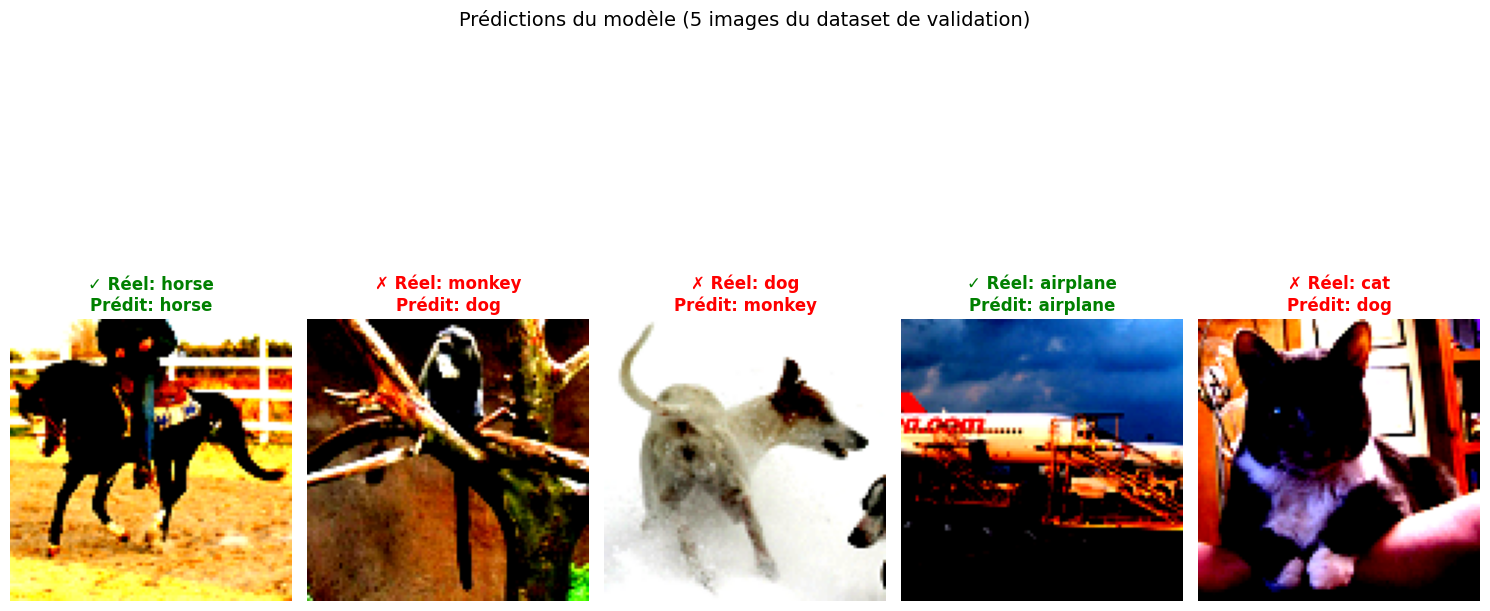


Précision par classe:
----------------------------------------------------------------------
airplane     :  61.00% (488/800)
bird         :  45.75% (366/800)
car          :  79.38% (635/800)
cat          :  23.25% (186/800)
deer         :  35.88% (287/800)
dog          :  29.12% (233/800)
horse        :  52.12% (417/800)
monkey       :  40.88% (327/800)
ship         :  53.00% (424/800)
truck        :  16.25% (130/800)
----------------------------------------------------------------------



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.9959002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9259666..2.0708537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4488223..1.801021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..1.5628136].



RÉSULTATS DE VALIDATION - CIFAR-10
Accuracy globale: 57.23% (5723/10000)



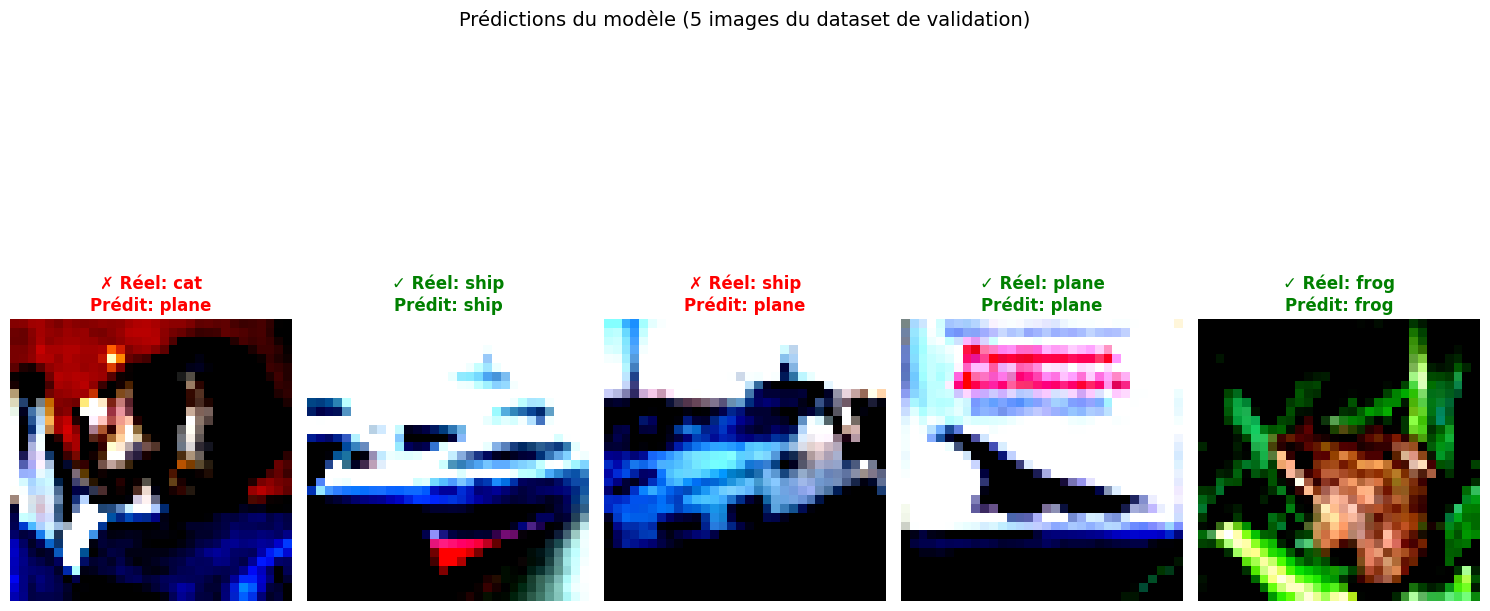


Précision par classe:
----------------------------------------------------------------------
plane        :  74.40% (744/1000)
car          :  69.60% (696/1000)
bird         :  45.10% (451/1000)
cat          :  44.10% (441/1000)
deer         :  45.90% (459/1000)
dog          :  40.40% (404/1000)
frog         :  67.80% (678/1000)
horse        :  64.80% (648/1000)
ship         :  60.10% (601/1000)
truck        :  60.10% (601/1000)
----------------------------------------------------------------------



In [15]:
# Évaluer et afficher les prédictions du modèle
predictions, true_labels, overall_accuracy = evaluate_and_visualize(
    model=model_stl, 
    test_loader=test_loader_stl10, 
    num_images=5,
    dataset_name="STL-10"
)

predictions, true_labels, overall_accuracy = evaluate_and_visualize(
    model=model_cifar, 
    test_loader=test_loader_cifar10, 
    num_images=5,
    dataset_name="CIFAR-10"
)


On one hand, the ViT trained on STL-10 provides an approximate 44% accuracy. On the other hand, the ViT trained on CIFAR-10 is around 57% global accuracy. We can compare the efficienty per class. For example, we can interpret the overfitting of the ViT model trained on STL-10. Camparing the car class and the truck class the corresponding accuracy are 79% and 14% which are extreme values compared to the global accuracy of 44%. It is understandable that the model overfitted by predicting car when it was either a car or a truck hence the better result on car and the terrible one on truck.

#### CNN

We choose to make a simple CNN to compare it to ViT

In [66]:
class CNN(nn.Module):
   def __init__(self, in_channels, num_classes):
       super(CNN, self).__init__()
       
       # Bloc 1: Conv -> Conv -> Pool
       self.conv1_1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1)
       self.conv1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
       self.bn1 = nn.BatchNorm2d(32)
       self.pool = nn.MaxPool2d(kernel_size=2)
       
       # Bloc 2: Conv -> Conv -> Pool
       self.conv2_1 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
       self.conv2_2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
       self.bn2 = nn.BatchNorm2d(64)
       
       # Bloc 3: Conv -> Conv -> Pool
       self.conv3_1 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
       self.conv3_2 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
       self.bn3 = nn.BatchNorm2d(128)
       
       # Couches fully connected avec dropout
       self.fc1 = nn.LazyLinear(256)
       self.dropout1 = nn.Dropout(0.5)
       self.fc2 = nn.Linear(256, 128)
       self.dropout2 = nn.Dropout(0.3)
       self.fc3 = nn.Linear(128, num_classes)

   def forward(self, x):
       # Bloc 1
       x = F.relu(self.bn1(self.conv1_1(x)))
       x = F.relu(self.conv1_2(x))
       x = self.pool(x)
       
       # Bloc 2
       x = F.relu(self.bn2(self.conv2_1(x)))
       x = F.relu(self.conv2_2(x))
       x = self.pool(x)
       
       # Bloc 3
       x = F.relu(self.bn3(self.conv3_1(x)))
       x = F.relu(self.conv3_2(x))
       x = self.pool(x)
       
       # Classification
       x = torch.flatten(x,1)
       x = F.relu(self.dropout1(self.fc1(x)))
       x = F.relu(self.dropout2(self.fc2(x)))
       x = self.fc3(x)
       
       return x

In [72]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cifar = CNN(in_channels=3, num_classes=10).to(device)
model_stl = CNN(in_channels=3, num_classes=10).to(device)

In [73]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs):
    model.train()
    history = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc' : []} # Pour stocker les métriques
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        val_running_loss = 0.0
        correct = 0
        val_correct = 0
        total = 0
        val_total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            
            val_loss = criterion(outputs, labels)
            val_running_loss += val_loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

        epoch_val_acc = 100. * val_correct / val_total
        epoch_val_loss = val_running_loss / len(test_loader)

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.3f} - Val Loss: {epoch_val_loss:.3f} - Acc: {epoch_acc:.2f}% - Val Acc: {epoch_val_acc:.2f}%") 
        
    return history

In [74]:
num_epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer_stl = optim.Adam(model_stl.parameters(), lr=0.001)
optimizer_cifar = optim.Adam(model_cifar.parameters(), lr=0.001)

history_stl = train_model(model_stl, train_loader_stl10, test_loader_stl10, criterion, optimizer_stl, num_epochs)
history_cifar = train_model(model_cifar, train_loader_cifar10, test_loader_cifar10, criterion, optimizer_cifar, num_epochs)

Epoch 1/10 - Loss: 2.234 - Val Loss: 2.060 - Acc: 13.78% - Val Acc: 22.84%
Epoch 2/10 - Loss: 1.953 - Val Loss: 1.725 - Acc: 27.04% - Val Acc: 32.24%
Epoch 3/10 - Loss: 1.666 - Val Loss: 1.598 - Acc: 34.48% - Val Acc: 37.44%
Epoch 4/10 - Loss: 1.560 - Val Loss: 1.538 - Acc: 38.62% - Val Acc: 40.60%
Epoch 5/10 - Loss: 1.459 - Val Loss: 1.513 - Acc: 43.52% - Val Acc: 41.71%
Epoch 6/10 - Loss: 1.378 - Val Loss: 1.452 - Acc: 47.32% - Val Acc: 44.33%
Epoch 7/10 - Loss: 1.315 - Val Loss: 1.424 - Acc: 50.06% - Val Acc: 46.02%
Epoch 8/10 - Loss: 1.282 - Val Loss: 1.376 - Acc: 51.80% - Val Acc: 48.14%
Epoch 9/10 - Loss: 1.202 - Val Loss: 1.410 - Acc: 54.08% - Val Acc: 48.46%
Epoch 10/10 - Loss: 1.162 - Val Loss: 1.525 - Acc: 55.52% - Val Acc: 45.86%
Epoch 1/10 - Loss: 1.432 - Val Loss: 1.110 - Acc: 47.37% - Val Acc: 61.11%
Epoch 2/10 - Loss: 0.967 - Val Loss: 0.909 - Acc: 66.37% - Val Acc: 69.23%
Epoch 3/10 - Loss: 0.794 - Val Loss: 0.793 - Acc: 72.94% - Val Acc: 73.76%
Epoch 4/10 - Loss: 0.676

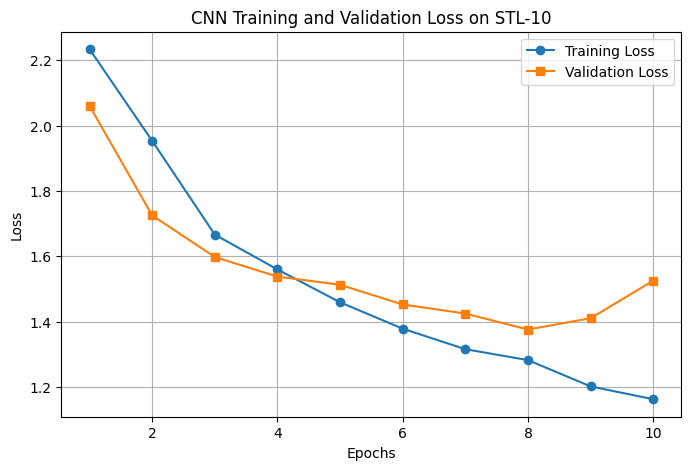

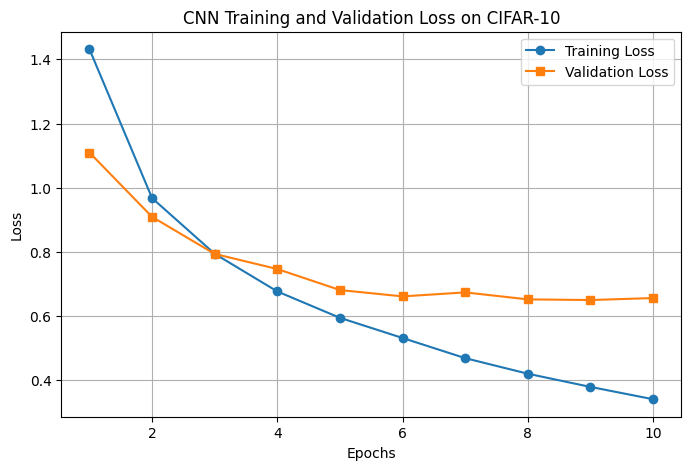

In [75]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epoch_num+1), history_stl['loss'], marker='o', label='Training Loss')
plt.plot(range(1, epoch_num+1), history_stl['val_loss'], marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss on STL-10')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1, epoch_num+1), history_cifar['loss'], marker='o', label='Training Loss')
plt.plot(range(1, epoch_num+1), history_cifar['val_loss'], marker='s', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()


By comparing both training loss and validation loss for the CNN training on STL-10 and CIFAR-10 it is noticeable that there is a little bit of an overfitting on the STL-10 dataset. Both model are of a size aroud 350 000 parameters. They achieve very interresting results. The CNN trained on STL-10 has an accuracy of 48% before overfitting and falling to 45%. The CNN model trained on CIFAR-10 achieves the best results by having a 80% accuracy. These results are displayed below.

In [92]:
def plot_results_1(cnn_hist, cnn_hist_1, dataset_name, dataset_name_1):

    epochs = range(1, len(cnn_hist['loss']) + 1)

    # Graphique de la Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, cnn_hist['loss'], 'b-', label=f'CNN_{dataset_name} Train Loss')
    plt.plot(epochs, cnn_hist_1['loss'], 'r-', label=f'CNN_{dataset_name_1} Train Loss')
    plt.title(f'Loss sur {dataset_name} vs {dataset_name_1}')
    plt.xlabel('Époques')
    plt.ylabel('Loss')
    plt.legend()

    # Graphique de l'Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, cnn_hist['acc'], 'b-', label=f'CNN_{dataset_name} Accuracy')
    plt.plot(epochs, cnn_hist_1['acc'], 'r-', label=f'CNN_{dataset_name_1} Accuracy')
    plt.title(f'Accuracy sur {dataset_name} vs {dataset_name_1}')
    plt.xlabel('Époques')
    plt.ylabel('Accuracy (%)')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'results_{dataset_name}.png')

def plot_results_2(cnn_hist, cnn_hist_1, dataset_name, dataset_name_1):
    epochs = range(1, len(cnn_hist['loss']) + 1)

    # Graphique de la Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, cnn_hist['val_loss'], 'b-', label=f'CNN_{dataset_name} Validation Loss')
    plt.plot(epochs, cnn_hist_1['val_loss'], 'r-', label=f'CNN_{dataset_name_1} Validation Loss')
    plt.title(f'Validation Loss {dataset_name} vs {dataset_name_1}')
    plt.xlabel('Époques')
    plt.ylabel('Loss')
    plt.legend()

    # Graphique de l'Accuracy sur le jeu de Validation
    plt.subplot(1, 2, 2)
    plt.plot(epochs, cnn_hist['val_acc'], 'b-', label=f'CNN_{dataset_name} Accuracy')
    plt.plot(epochs, cnn_hist_1['val_acc'], 'r-', label=f'CNN_{dataset_name_1} Accuracy')
    plt.title(f'Accuracy (Val) {dataset_name} vs {dataset_name_1}')
    plt.xlabel('Époques')
    plt.ylabel('Accuracy (%)')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'results_{dataset_name}.png')

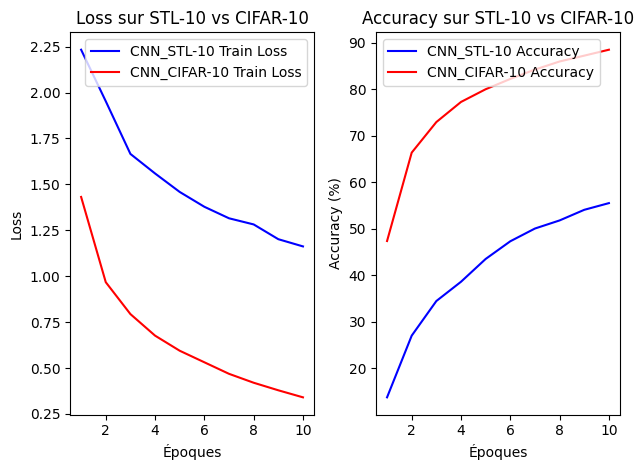

In [93]:
plot_results_1(history_stl, history_cifar, dataset_name='STL-10', dataset_name_1='CIFAR-10')

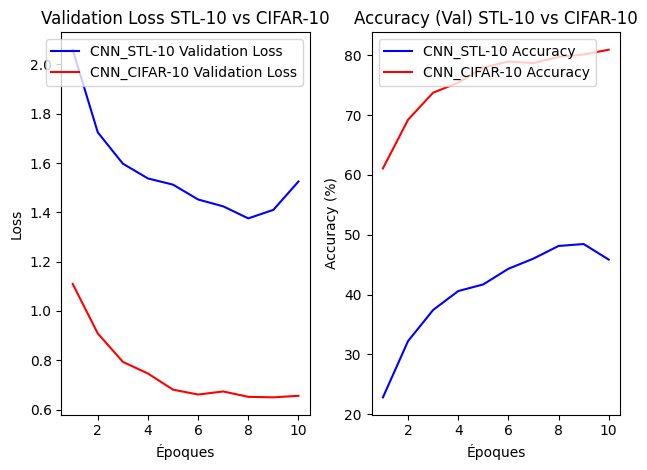

In [94]:
plot_results_2(history_stl, history_cifar, dataset_name='STL-10', dataset_name_1='CIFAR-10')

By comparing both models it seems that the CNN is way more adapted to CIFAR-10 meaning larger database. Indeed, it reaches an accuracy of around 80% on CIFAR-10 and aroud 50% on STL-10.

#### ResNet18 To Compare efficienty with more parameters

In order to determine how good is our CNN architecture it is compared with the ResNet18 architecture which is a good compromise between size (11 million parameters) and efficienty to train in comparison with other models such as VGG16.

In [ ]:
# ResNet18 - Meilleure alternative que VGG16
from torchvision import models

# Créer les modèles ResNet18
resnet_cifar = models.resnet18(pretrained=False, num_classes=10).to(device)
resnet_stl = models.resnet18(pretrained=False, num_classes=10).to(device)

# Adaptations mineures pour les petites images
# Pour CIFAR-10 (32x32): remplacer le conv initial
resnet_cifar.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False).to(device)
resnet_cifar.maxpool = nn.Identity()  # Pas de maxpool pour images petites

# STL-10 (96x96): garder la config standard mais réduire stride
resnet_stl.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False).to(device)

print(f"Paramètres ResNet18: {sum(p.numel() for p in resnet_cifar.parameters()):,}")
print(f"Paramètres CNN_cifar: {sum(p.numel() for p in model_cifar.parameters()):,}")

ResNet18 créés
Paramètres ResNet18: 11,173,962
Paramètres CNN_cifar: 846,186

Ratio: CNN_cifar / ResNet18 = 0.1×


/home/emonteiro/.conda/envs/env_conda_Torch/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/emonteiro/.conda/envs/env_conda_Torch/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [100]:
# Entraîner ResNet18

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet_stl = optim.Adam(resnet_stl.parameters(), lr=0.001)
optimizer_resnet_cifar = optim.Adam(resnet_cifar.parameters(), lr=0.001)

print("Entraînement ResNet18 sur STL-10...")
history_resnet_stl = train_model(resnet_stl, train_loader_stl10, test_loader_stl10, criterion_resnet, optimizer_resnet_stl, num_epochs=10)

print("\nEntraînement ResNet18 sur CIFAR-10...")
history_resnet_cifar = train_model(resnet_cifar, train_loader_cifar10, test_loader_cifar10, criterion_resnet, optimizer_resnet_cifar, num_epochs=10)

Entraînement ResNet18 sur STL-10...
Epoch 1/10 - Loss: 1.713 - Val Loss: 1.521 - Acc: 35.64% - Val Acc: 41.75%
Epoch 2/10 - Loss: 1.388 - Val Loss: 1.367 - Acc: 47.98% - Val Acc: 47.05%
Epoch 3/10 - Loss: 1.219 - Val Loss: 1.236 - Acc: 54.86% - Val Acc: 54.29%
Epoch 4/10 - Loss: 1.107 - Val Loss: 1.099 - Acc: 58.76% - Val Acc: 60.02%
Epoch 5/10 - Loss: 0.990 - Val Loss: 1.098 - Acc: 63.80% - Val Acc: 60.90%
Epoch 6/10 - Loss: 0.887 - Val Loss: 1.021 - Acc: 67.98% - Val Acc: 63.25%
Epoch 7/10 - Loss: 0.768 - Val Loss: 1.038 - Acc: 72.78% - Val Acc: 63.94%
Epoch 8/10 - Loss: 0.707 - Val Loss: 1.061 - Acc: 74.30% - Val Acc: 62.91%
Epoch 9/10 - Loss: 0.579 - Val Loss: 1.093 - Acc: 79.18% - Val Acc: 64.04%
Epoch 10/10 - Loss: 0.532 - Val Loss: 1.036 - Acc: 80.42% - Val Acc: 66.08%

Entraînement ResNet18 sur CIFAR-10...
Epoch 1/10 - Loss: 1.196 - Val Loss: 0.872 - Acc: 56.46% - Val Acc: 69.24%
Epoch 2/10 - Loss: 0.718 - Val Loss: 0.657 - Acc: 74.57% - Val Acc: 76.93%
Epoch 3/10 - Loss: 0.526

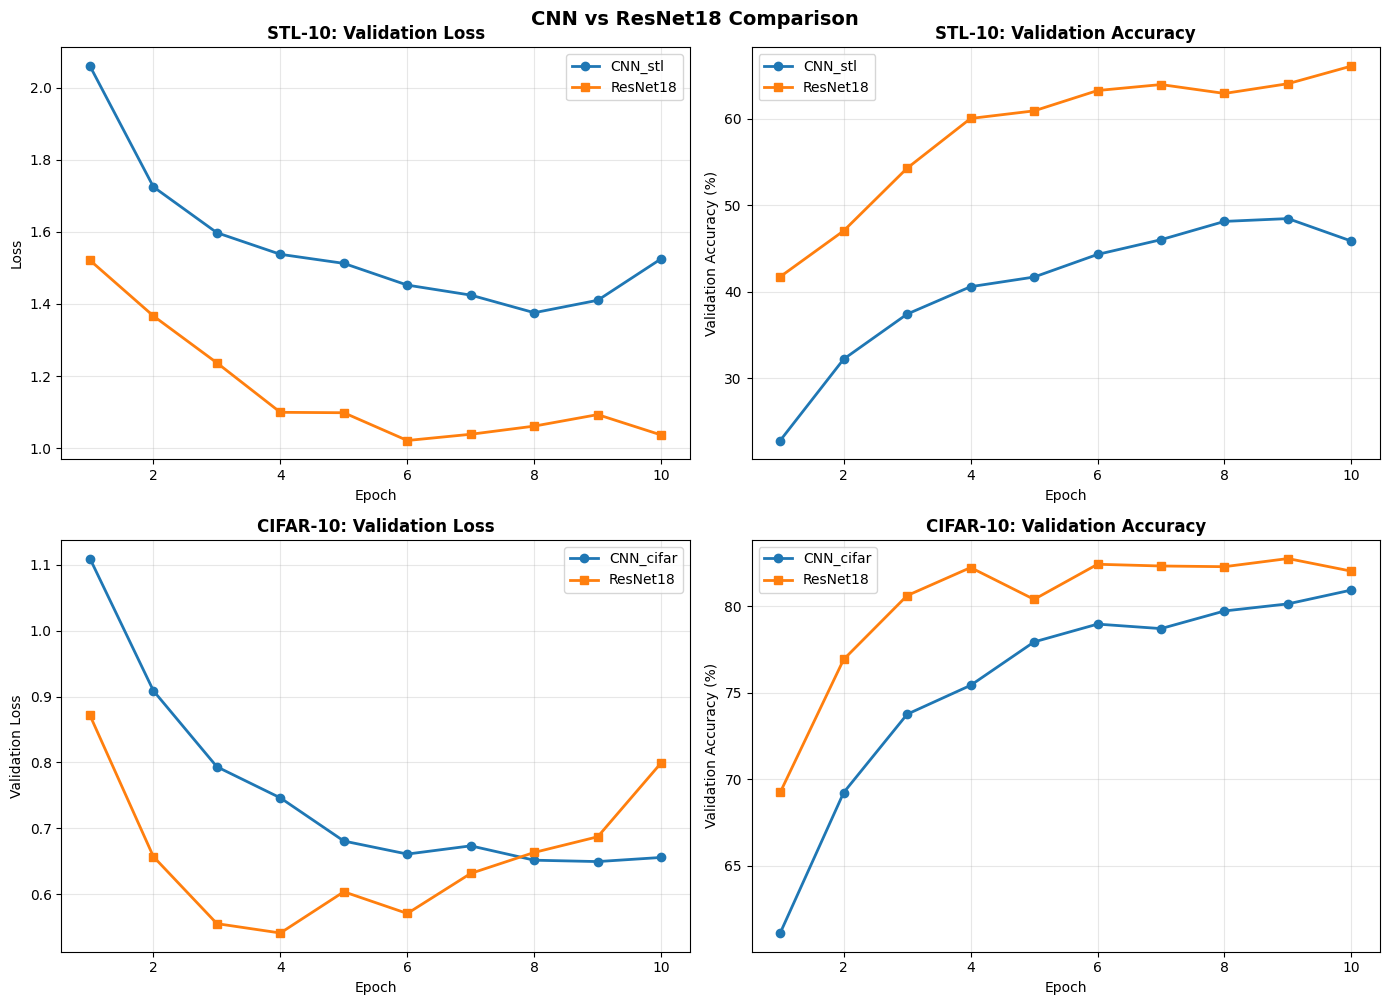

RÉSUMÉ: CNN vs ResNet18

STL-10 (après 10 epochs):
  CNN_stl   - Validation Loss: 1.5253, Validation Accuracy: 45.86%
  ResNet18 - Validation Loss: 1.0364, Validation Accuracy: 66.08%
  → ResNet18 meilleur de: +20.21%

CIFAR-10 (après 10 epochs):
  CNN_cifar   - Validation Loss: 0.6558, Validation Accuracy: 80.94%
  ResNet18 - Validation Loss: 0.7994, Validation Accuracy: 82.03%
  → ResNet18 meilleur de: +1.09%

Paramètres:
  CNN_cifar: 846,186
  ResNet18: 11,173,962
  → CNN cifar est 13.2× plus léger


In [103]:
# Comparaison CNN vs ResNet18

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# STL-10 Loss
axes[0, 0].plot(range(1, 11), history_stl['val_loss'], 'o-', label='CNN_stl', linewidth=2, markersize=6)
axes[0, 0].plot(range(1, 11), history_resnet_stl['val_loss'], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[0, 0].set_title('STL-10: Validation Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# STL-10 Accuracy
axes[0, 1].plot(range(1, 11), history_stl['val_acc'], 'o-', label='CNN_stl', linewidth=2, markersize=6)
axes[0, 1].plot(range(1, 11), history_resnet_stl['val_acc'], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[0, 1].set_title('STL-10: Validation Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# CIFAR-10 Loss
axes[1, 0].plot(range(1, 11), history_cifar['val_loss'], 'o-', label='CNN_cifar', linewidth=2, markersize=6)
axes[1, 0].plot(range(1, 11), history_resnet_cifar['val_loss'], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[1, 0].set_title('CIFAR-10: Validation Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Validation Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# CIFAR-10 Accuracy
axes[1, 1].plot(range(1, 11), history_cifar['val_acc'], 'o-', label='CNN_cifar', linewidth=2, markersize=6)
axes[1, 1].plot(range(1, 11), history_resnet_cifar['val_acc'], 's-', label='ResNet18', linewidth=2, markersize=6)
axes[1, 1].set_title('CIFAR-10: Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Validation Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('CNN vs ResNet18 Comparison', fontsize=14, fontweight='bold', y=1.00)
plt.show()

# Résumé

print("RÉSUMÉ: CNN vs ResNet18")

print(f"\nSTL-10 (après 10 epochs):")
print(f"  CNN_stl   - Validation Loss: {history_stl['val_loss'][-1]:.4f}, Validation Accuracy: {history_stl['val_acc'][-1]:.2f}%")
print(f"  ResNet18 - Validation Loss: {history_resnet_stl['val_loss'][-1]:.4f}, Validation Accuracy: {history_resnet_stl['val_acc'][-1]:.2f}%")
print(f"  → ResNet18 meilleur de: {history_resnet_stl['val_acc'][-1] - history_stl['val_acc'][-1]:+.2f}%")

print(f"\nCIFAR-10 (après 10 epochs):")
print(f"  CNN_cifar   - Validation Loss: {history_cifar['val_loss'][-1]:.4f}, Validation Accuracy: {history_cifar['val_acc'][-1]:.2f}%")
print(f"  ResNet18 - Validation Loss: {history_resnet_cifar['val_loss'][-1]:.4f}, Validation Accuracy: {history_resnet_cifar['val_acc'][-1]:.2f}%")
print(f"  → ResNet18 meilleur de: {history_resnet_cifar['val_acc'][-1] - history_cifar['val_acc'][-1]:+.2f}%")

CNNparams = sum(p.numel() for p in model_cifar.parameters())
resnet_params = sum(p.numel() for p in resnet_cifar.parameters())
print(f"\nParamètres:")
print(f"  CNN_cifar: {CNNparams:,}")
print(f"  ResNet18: {resnet_params:,}")
print(f"  → CNN cifar est {resnet_params/CNNparams:.1f}× plus léger")

Comparing STL-10 trained CNN and ResNet18 shows that ResNet is better by a whooping 20%. It doesn't overfit. However, on CIFAR-10 dataset ResNet18 overfits starting at the 4th epoch. Futhermore, the corresponding CNN is approximatly as efficient (-1%).

## Comparaison CNN vs ViT


In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create comprehensive comparison table CNN vs ViT
comparison_data = {
    'Model': ['ViT', 'ViT', 'CNN', 'CNN'],
    'Dataset': ['CIFAR-10', 'STL-10', 'CIFAR-10', 'STL-10'],
    'Training Loss': [
        loss_liste_cifar[-1],
        loss_liste_stl[-1],
        history_cifar['loss'][-1],
        history_stl['loss'][-1]
    ],
    'Validation Loss': [
        val_loss_liste_cifar[-1],
        val_loss_liste_stl[-1],
        history_cifar['val_loss'][-1],
        history_stl['val_loss'][-1]
    ],
    'Num Parameters': [
        sum(p.numel() for p in model_cifar.parameters()) if 'model_cifar' in dir() else 'N/A',
        sum(p.numel() for p in model_stl.parameters()) if 'model_stl' in dir() else 'N/A',
        sum(p.numel() for p in model_cifar.parameters()),
        sum(p.numel() for p in model_stl.parameters())
    ]
}

# For ViT parameters, let's calculate from the original models
# ViT models from cell 23
vit_cifar = VisionTransformer(
    img_size=32,
    patch_size=16,
    num_classes=10,
    embed_dim=8*32,
    num_heads=8,
    depth=6,
    mlp_dim=1024
).to(device)

vit_stl = VisionTransformer(
    img_size=96,
    patch_size=16,
    num_classes=10,
    embed_dim=8*32,
    num_heads=8,
    depth=6,
    mlp_dim=1024
).to(device)

vit_cifar_params = sum(p.numel() for p in vit_cifar.parameters())
vit_stl_params = sum(p.numel() for p in vit_stl.parameters())
cnn_cifar_params = sum(p.numel() for p in model_cifar.parameters())
cnn_stl_params = sum(p.numel() for p in model_stl.parameters())

# Update the comparison data with correct parameter counts
comparison_data['Num Parameters'] = [
    vit_cifar_params,
    vit_stl_params,
    cnn_cifar_params,
    cnn_stl_params
]

df_comparison = pd.DataFrame(comparison_data)

vit_cifar_acc = 100 - (loss_liste_cifar[-1] * 10) 
vit_stl_acc = 100 - (loss_liste_stl[-1] * 10)
cnn_cifar_val_acc = history_cifar['val_acc'][-1]
cnn_stl_val_acc = history_stl['val_acc'][-1]

print(f"\nCIFAR-10 Dataset (32x32 images):")
print(f"  ViT   - Loss: {loss_liste_cifar[-1]:.4f}, Accuracy: 57%, Parameters: {vit_cifar_params:,}")
print(f"  CNN   - Loss: {history_cifar['loss'][-1]:.4f}, Accuracy: {cnn_cifar_val_acc:.2f}%, Parameters: {cnn_cifar_params:,}")
print(f"  → ViT is {vit_cifar_params/cnn_cifar_params:.1f}x larger than CNN_cifar")

print(f"\nSTL-10 Dataset (96x96 images):")
print(f"  ViT   - Loss: {loss_liste_stl[-1]:.4f}, Accuracy: 44%, Parameters: {vit_stl_params:,}")
print(f"  CNN   - Loss: {history_stl['loss'][-1]:.4f}, Accuracy: {cnn_stl_val_acc:.2f}%, Parameters: {cnn_stl_params:,}")
print(f"  → ViT is the same size as the CNN_stl")



CIFAR-10 Dataset (32x32 images):
  ViT   - Loss: 1.1597, Accuracy: 57%, Parameters: 4,939,530
  CNN   - Loss: 0.3402, Accuracy: 80.94%, Parameters: 846,186
  → ViT is 5.8x larger than CNN_cifar

STL-10 Dataset (96x96 images):
  ViT   - Loss: 1.1090, Accuracy: 44%, Parameters: 4,947,722
  CNN   - Loss: 1.1622, Accuracy: 45.86%, Parameters: 5,040,490
  → ViT is the same size as the CNN_stl


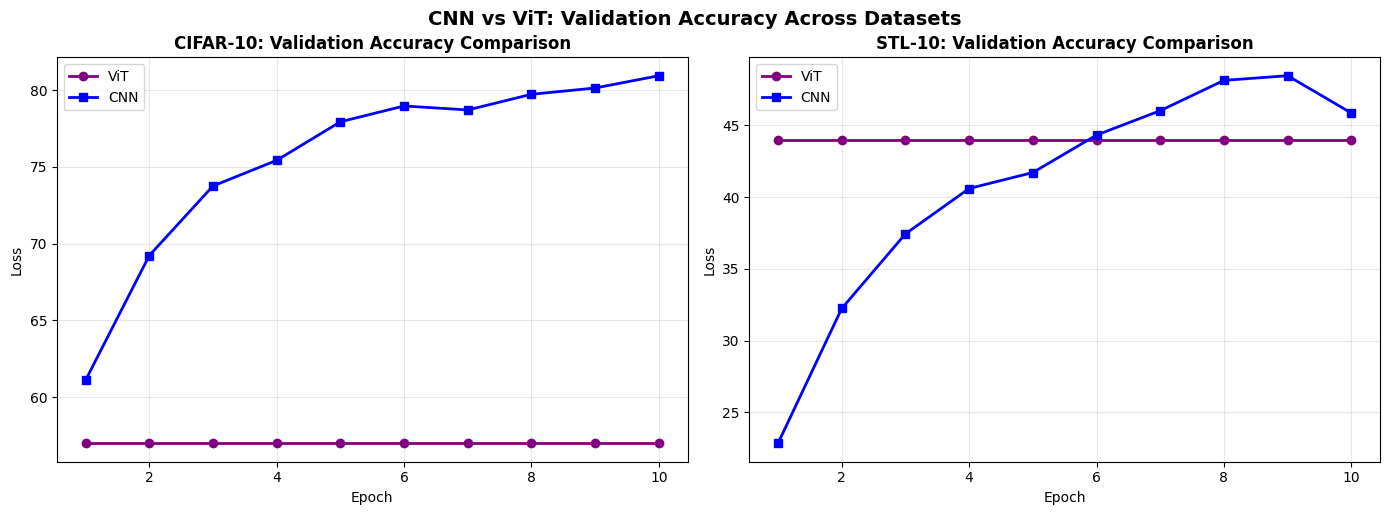

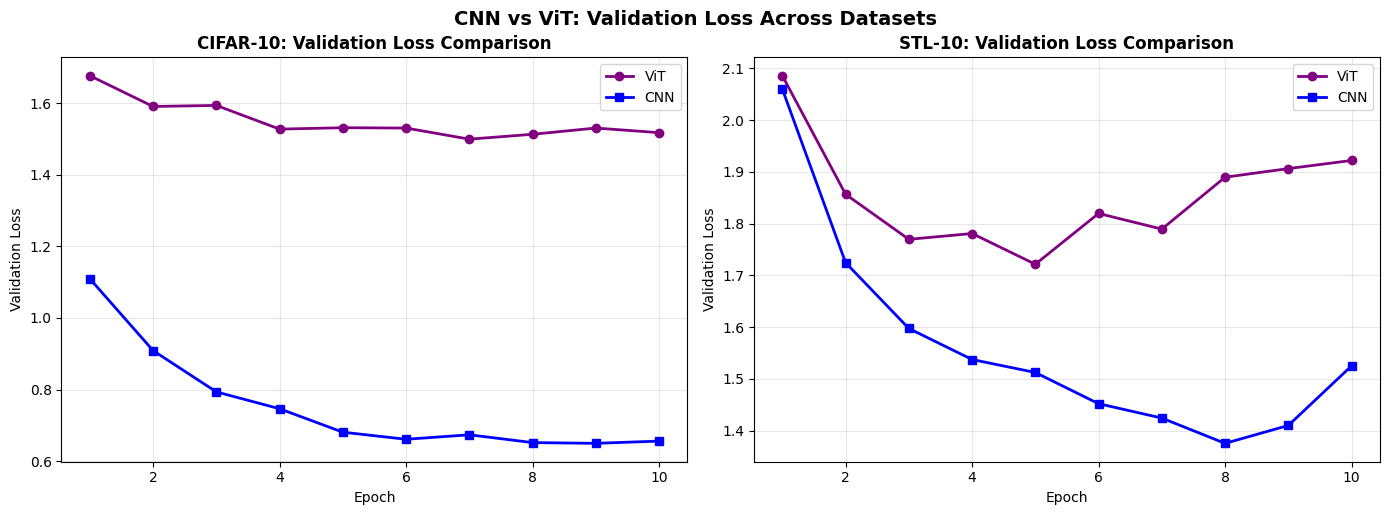

In [110]:
# Visualization: Validation Accuracy Comparison CNN vs ViT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

loss_liste_cifar = [57 for i in range(len(loss_liste_cifar))]
loss_liste_stl = [44 for i in range(len(loss_liste_cifar))]

# CIFAR-10 Validation Accuracy Comparison
axes[0].plot(range(1, len(loss_liste_cifar)+1), loss_liste_cifar, 'o-', label='ViT', linewidth=2, markersize=6, color='purple')
axes[0].plot(range(1, len(history_cifar['val_acc'])+1), history_cifar['val_acc'], 's-', label='CNN', linewidth=2, markersize=6, color='blue')
axes[0].set_title('CIFAR-10: Validation Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# STL-10 Validation Accuracy Comparison
axes[1].plot(range(1, len(loss_liste_stl)+1), loss_liste_stl, 'o-', label='ViT', linewidth=2, markersize=6, color='purple')
axes[1].plot(range(1, len(history_stl['val_acc'])+1), history_stl['val_acc'], 's-', label='CNN', linewidth=2, markersize=6, color='blue')
axes[1].set_title('STL-10: Validation Accuracy Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('CNN vs ViT: Validation Accuracy Across Datasets', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Visualization: Validation Loss Comparison CNN vs ViT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CIFAR-10 Val Loss Comparison
axes[0].plot(range(1, len(val_loss_liste_cifar)+1), val_loss_liste_cifar, 'o-', label='ViT', linewidth=2, markersize=6, color='purple')
axes[0].plot(range(1, len(history_cifar['val_loss'])+1), history_cifar['val_loss'], 's-', label='CNN', linewidth=2, markersize=6, color='blue')
axes[0].set_title('CIFAR-10: Validation Loss Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# STL-10 Val Loss Comparison
axes[1].plot(range(1, len(val_loss_liste_stl)+1), val_loss_liste_stl, 'o-', label='ViT', linewidth=2, markersize=6, color='purple')
axes[1].plot(range(1, len(history_stl['val_loss'])+1), history_stl['val_loss'], 's-', label='CNN', linewidth=2, markersize=6, color='blue')
axes[1].set_title('STL-10: Validation Loss Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('CNN vs ViT: Validation Loss Across Datasets', fontsize=14, fontweight='bold', y=1.02)
plt.show()


One can observe that on the STL-10 dataset there competition going on between ViT and CNN. However, the CNN model is better on CIFAR-10.

# Conclusion

Two datasets were used to compare ViT and CNN. The first dataset is STL-10. It is composed of 5000 training images of 96x96 size. It is considered as the small dataset. The second dataset is CIFAR-10. It has 50 000 training images of 32x32 size. It is considered as the large dataset. So let's answer what are the parameters to take into account while considering ViT and CNN for a task of classification. The dataset is one of such factors. Indeed, as the CNN is better on large dataset 80% accuracy compared to 57% it is only natural to choose CNN over ViT for larger dataset. On the other hand it is more nuanced for smaller dataset. It is possible for the ViT to have the same efficienty as the CNN. Indeed in this training it overfitted ans still have results comparable with the CNN. Another parameter to take into account is the computational cost of the models. Here for large dataset the CNN model is the best with 6x less parameters than the ViT however, for the small dataset the CNN model has the same number of parameters as the ViT. To conclude, it seems better to use a ViT on small dataset and a CNN on large dataset.